# LOAD LIBRARIES

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns
import math
import json
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import shap
from scipy.stats import linregress
from diive.core.io.files import load_parquet

# CONFIGURATION

In [131]:
START_DATE, END_DATE = '2023-11-08', '2025-06-05'
TARGET_FLUX = 'NEE'
N_FOLDS = 10
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
CROSSVAL_SPLIT = 'time_blocks_eliza' # options: 'shuffle' or 'kfold' or 'custom_time_blocks' or 'time_blocks_eliza'
PARCEL_CERTAIN = True
LOG_TRANSFORM = False
ADD_ID = False
UNDERSAMPLE = False

# LOAD DATA

In [132]:
data_main = fluxes = load_parquet(filepath=r"../81.1_GapFillingDataset.parquet")
data_main = data_main.loc[START_DATE:END_DATE].copy()

# Add an id column to account for the proximity of values as the timestamp is continuous without gaps
if ADD_ID:
    data_main['id'] = range(0, len(data_main))

data_main

Loaded .parquet file ../81.1_GapFillingDataset.parquet (0.305 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,NEE_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,NEE_U50_f_reddyproc,GPP_U50_f_reddyproc,Reco_U50_reddyproc,parcel,parcel_certainty,SW_IN_POT,prec,ta,ppfd,...,ts_0.15_gfXG_diff6h,ts_0.15_gfXG_diff12h,ts_0.15_gfXG_diff24h,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,NaN,-0.111997,-3.231648,NaN,NaN,-3.231648,1.991226,-0.238835,1.752390,B,certain,0.0,0.0,5.333333,0.0,...,-1.485105,-1.116706,-1.152150,-0.275176,-0.379151,2.956382,-1.867139,0.684108,-0.057099,-0.193433,-0.188894,0.055964,-1.641550,-0.086146,0.576043
2023-11-08 00:45:00,NaN,0.100302,NaN,NaN,0.100302,NaN,2.035776,-0.203400,1.832376,B,certain,0.0,0.0,5.966667,0.0,...,-1.413669,-1.202539,-1.002316,-0.315639,-0.100172,2.819366,-3.607107,0.860526,-0.241229,-0.051464,0.009568,0.016644,-2.340741,0.001028,0.291943
2023-11-08 01:15:00,NaN,0.239428,NaN,NaN,0.239428,NaN,2.026159,-0.210755,1.815404,B,certain,0.0,0.0,5.833333,0.0,...,-1.482971,-1.423575,-1.251268,0.154263,0.054827,2.845686,-2.065147,0.363886,0.902289,-0.146880,0.084459,0.138010,-0.829823,0.242660,0.618842
2023-11-08 01:45:00,NaN,-0.184917,6.746138,NaN,NaN,NaN,2.026159,-0.206519,1.819640,B,certain,0.0,0.0,5.866667,0.0,...,-1.613288,-1.456775,-1.194985,0.190084,0.205121,2.216312,-2.011537,0.459781,0.395772,-0.234554,-0.023746,0.307449,-0.724752,0.260016,0.686303
2023-11-08 02:15:00,NaN,0.358358,3.168362,NaN,0.358358,3.168362,2.025592,-0.218648,1.806944,B,certain,0.0,0.0,5.766667,0.0,...,-1.522183,-1.730865,-1.054997,0.243881,0.243286,1.087768,-1.790441,0.750873,1.037005,-0.187335,-0.028905,0.178615,-0.724348,0.032634,0.695635
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,0.0,15.833333,0.0,...,0.564180,1.105808,0.251504,0.137646,0.269348,-0.182687,-1.770683,-2.475835,-0.177535,-1.379082,-1.916712,-1.061214,-4.208609,-5.629534,-3.817729
2025-06-05 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,0.0,15.733333,0.0,...,-0.058895,1.185266,0.415243,-0.006586,0.174141,-0.309516,-4.491630,-2.066168,-1.321539,-1.091476,-1.879544,-0.962736,-4.909742,-6.854152,-4.700644
2025-06-05 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,0.0,16.200000,0.0,...,-0.417110,0.829382,0.121118,0.319431,0.265461,-0.070498,-5.166902,-3.647422,-1.775911,-1.190896,-1.739450,-0.961502,-4.913663,-6.580284,-4.667567


In [133]:
TARGET = f'{TARGET_FLUX}_L3.3_CUT_50_QCF0'
print(f'The target variable is {TARGET}')

mean_nan_size = (
    data_main[TARGET]
    .isna()
    .ne(data_main[TARGET].isna().shift())
    .cumsum()
    .where(data_main[TARGET].isna())
    .dropna()
    .value_counts()
    .mean()
)
print("\nMean size of consecutive NaNs in the target variable:", mean_nan_size)

# Remove NAs of the target
data = data_main[data_main[TARGET].notna()].copy()

# Keep only data where we are sure about parcel attribution
if PARCEL_CERTAIN:
    data = data[data['parcel_certainty'] == 'certain'].copy()
    print('\nKeeping only data when we are highly confident on the parcel attribution')

The target variable is NEE_L3.3_CUT_50_QCF0

Mean size of consecutive NaNs in the target variable: 5.646989835809226

Keeping only data when we are highly confident on the parcel attribution


# SELECT FEATURES

In [134]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 23
# path = 'ranked_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]

# Remove specific variables if you want
#to_remove = ('flux_nee', 'prec')
#selected_features = [c for c in selected_features if not c.startswith(to_remove)]

selected_features = [
'SW_IN_POT',
'ppfd',
'n_decay_timed_parcelA',
'n_decay_timed_parcelB',
'timesince_harvest',
'soil_preparation_timed',
'sowing_timed',
'ts_0.3_gfXG_roll3hmean'
]

data

,NEE_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,NEE_U50_f_reddyproc,GPP_U50_f_reddyproc,Reco_U50_reddyproc,parcel,parcel_certainty,SW_IN_POT,prec,ta,ppfd,...,ts_0.15_gfXG_diff6h,ts_0.15_gfXG_diff12h,ts_0.15_gfXG_diff24h,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-22 11:15:00,0.870527,0.232296,NaN,0.870527,0.232296,NaN,0.870527,0.636198,1.506725,A,certain,508.623,0.238,3.166667,100.485834,...,1.337738,-1.317629,-1.124065,-0.114594,-0.332553,-0.728411,3.107422,2.125116,2.928839,0.191085,0.508545,1.199013,0.861383,1.659645,2.910261
2023-11-22 11:45:00,0.844507,0.034880,10.930058,0.844507,0.034880,NaN,0.844507,0.654459,1.498966,A,certain,531.452,0.000,3.043333,78.235791,...,1.354507,-1.310291,-1.103999,-0.151393,-0.363302,-0.746003,3.178569,1.489788,2.715081,0.431137,0.113344,1.485885,-0.853927,-1.348990,1.416971
2023-11-22 12:15:00,0.629330,0.130513,5.660535,0.629330,0.130513,5.660535,0.629330,0.858032,1.487362,A,certain,539.106,0.000,3.056667,82.407674,...,1.424386,0.177859,-0.610469,-0.182571,-0.307641,-0.746924,3.229933,2.572290,3.131318,0.380090,0.034436,1.168242,-1.600306,-1.980507,0.359746
2023-11-22 12:45:00,0.602554,0.136325,9.307767,0.602554,0.136325,9.307767,0.602554,0.884808,1.487362,A,certain,531.452,0.000,3.000000,98.399892,...,1.402835,0.531006,-0.471439,-0.234726,-0.332534,-0.798875,2.241630,1.659547,2.835273,0.118894,0.003378,1.077855,-1.631950,-1.463329,-0.060023
2023-11-22 13:15:00,0.477717,0.143298,0.783960,0.477717,0.143298,NaN,0.477717,1.025126,1.502843,A,certain,508.623,0.000,2.946667,117.173366,...,1.406002,0.629119,-0.580503,-0.276385,-0.414082,-0.429772,2.834057,1.153027,2.859792,0.504430,0.103235,1.167029,-3.529501,-1.774765,-0.246205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,10.578562,0.524032,2.489636,10.578562,0.524032,NaN,10.578562,-1.558117,9.020445,B,certain,0.000,0.017,15.693333,0.000000,...,-0.335000,0.866111,-0.961666,0.205000,0.318334,-0.270000,-0.042154,-0.862990,-1.240195,-0.138894,-0.501428,-0.865616,-0.130630,-0.951387,-1.460515
2025-06-04 22:15:00,9.416519,NaN,-0.987718,9.416519,NaN,NaN,9.416519,-0.474679,8.941840,B,certain,0.000,0.034,15.516667,0.000000,...,-0.538334,0.745555,-0.901111,0.199444,0.353332,-0.281666,0.030612,-0.850980,-1.201306,-0.115306,-0.455520,-0.859899,-0.075635,-0.878298,-1.447001
2025-06-04 22:45:00,10.095010,-0.069384,2.160966,10.095010,-0.069384,2.160966,10.095010,-1.089414,9.005596,B,certain,0.000,0.425,15.660000,0.000000,...,-0.647778,0.575555,-0.836111,0.098889,0.368333,-0.310000,0.025945,-0.847119,-1.197830,-0.108815,-0.438437,-0.860283,-0.205865,-0.852473,-1.503494


# SELECT MODEL

In [135]:
# Load hyperparameters from JSON file
path = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(path, "r") as file:
    hyperparams = json.load(file)

# Print loaded hyperparameters (optional)
print("Loaded Hyperparameters:", hyperparams)

model = RandomForestRegressor(**hyperparams, random_state=42, n_jobs=-1, early_stopping_rounds=10, eval_metric="rmse") if MODEL_TYPE == 'RandomForest' else XGBRegressor(**hyperparams, random_state=42, n_jobs=-1)

Loaded Hyperparameters: {'colsample_bytree': 1, 'gamma': 0.2, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 300, 'subsample': 0.65}


# IMBALANCE HANDLING

## UNDER SAMPLING

In [136]:
if UNDERSAMPLE:
    quantile_cutoff = 0.8
    cutoff_value = data[TARGET].quantile(quantile_cutoff)
    print(f'Undersampling target data below: {cutoff_value}')
    # Split and undersample
    upper = data[data[TARGET] > cutoff_value]
    lower = data[data[TARGET] <= cutoff_value]
    # Undersample
    lower_sampled = lower.sample(frac=0.5, random_state=42)
    # Combine
    data = pd.concat([upper, lower_sampled]).sample(frac=1, random_state=42)
    # Resort data
    data = data.sort_index().reset_index(drop=False)  # keep the timestamp as a column
    data = data.set_index('TIMESTAMP_MIDDLE')    # and set it back as index if needed
    # Plot
    data[TARGET].plot(x_compat=True, style='.');

## LOG TRANSFORMATION

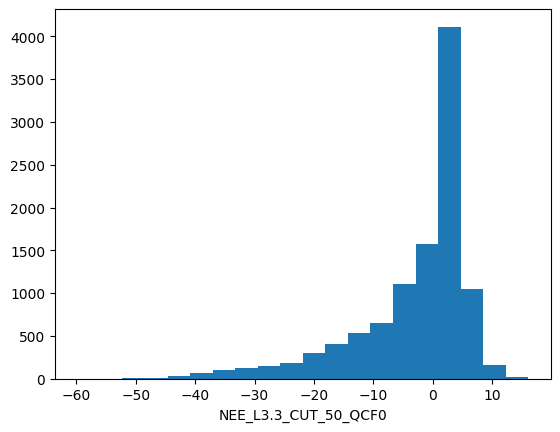

,NEE_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,NEE_U50_f_reddyproc,GPP_U50_f_reddyproc,Reco_U50_reddyproc,parcel,parcel_certainty,SW_IN_POT,prec,ta,ppfd,...,ts_0.15_gfXG_diff6h,ts_0.15_gfXG_diff12h,ts_0.15_gfXG_diff24h,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-22 11:15:00,0.870527,0.232296,NaN,0.870527,0.232296,NaN,0.870527,0.636198,1.506725,A,certain,508.623,0.238,3.166667,100.485834,...,1.337738,-1.317629,-1.124065,-0.114594,-0.332553,-0.728411,3.107422,2.125116,2.928839,0.191085,0.508545,1.199013,0.861383,1.659645,2.910261
2023-11-22 11:45:00,0.844507,0.034880,10.930058,0.844507,0.034880,NaN,0.844507,0.654459,1.498966,A,certain,531.452,0.000,3.043333,78.235791,...,1.354507,-1.310291,-1.103999,-0.151393,-0.363302,-0.746003,3.178569,1.489788,2.715081,0.431137,0.113344,1.485885,-0.853927,-1.348990,1.416971
2023-11-22 12:15:00,0.629330,0.130513,5.660535,0.629330,0.130513,5.660535,0.629330,0.858032,1.487362,A,certain,539.106,0.000,3.056667,82.407674,...,1.424386,0.177859,-0.610469,-0.182571,-0.307641,-0.746924,3.229933,2.572290,3.131318,0.380090,0.034436,1.168242,-1.600306,-1.980507,0.359746
2023-11-22 12:45:00,0.602554,0.136325,9.307767,0.602554,0.136325,9.307767,0.602554,0.884808,1.487362,A,certain,531.452,0.000,3.000000,98.399892,...,1.402835,0.531006,-0.471439,-0.234726,-0.332534,-0.798875,2.241630,1.659547,2.835273,0.118894,0.003378,1.077855,-1.631950,-1.463329,-0.060023
2023-11-22 13:15:00,0.477717,0.143298,0.783960,0.477717,0.143298,NaN,0.477717,1.025126,1.502843,A,certain,508.623,0.000,2.946667,117.173366,...,1.406002,0.629119,-0.580503,-0.276385,-0.414082,-0.429772,2.834057,1.153027,2.859792,0.504430,0.103235,1.167029,-3.529501,-1.774765,-0.246205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,10.578562,0.524032,2.489636,10.578562,0.524032,NaN,10.578562,-1.558117,9.020445,B,certain,0.000,0.017,15.693333,0.000000,...,-0.335000,0.866111,-0.961666,0.205000,0.318334,-0.270000,-0.042154,-0.862990,-1.240195,-0.138894,-0.501428,-0.865616,-0.130630,-0.951387,-1.460515
2025-06-04 22:15:00,9.416519,NaN,-0.987718,9.416519,NaN,NaN,9.416519,-0.474679,8.941840,B,certain,0.000,0.034,15.516667,0.000000,...,-0.538334,0.745555,-0.901111,0.199444,0.353332,-0.281666,0.030612,-0.850980,-1.201306,-0.115306,-0.455520,-0.859899,-0.075635,-0.878298,-1.447001
2025-06-04 22:45:00,10.095010,-0.069384,2.160966,10.095010,-0.069384,2.160966,10.095010,-1.089414,9.005596,B,certain,0.000,0.425,15.660000,0.000000,...,-0.647778,0.575555,-0.836111,0.098889,0.368333,-0.310000,0.025945,-0.847119,-1.197830,-0.108815,-0.438437,-0.860283,-0.205865,-0.852473,-1.503494


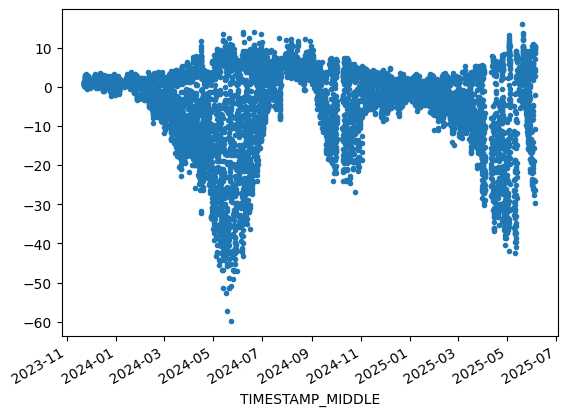

In [137]:
min_value = data[TARGET].min()

def log_transform(x):
    return np.log1p(x - min_value) if min_value < 0 else np.log1p(x)

def inverse_log_transform(x):
    return np.expm1(x) + min_value if min_value < 0 else np.expm1(x)

if LOG_TRANSFORM:
    data[TARGET] = log_transform(data[TARGET])

# Show histogram of TARGET
plt.hist(data[TARGET], bins=20)
plt.xlabel(TARGET)
plt.show()

# Show timeseries
data[TARGET].plot(x_compat=True, style='.');

data

# SUBSET FOR PERIOD AND PARCEL

In [138]:
# Define crop periods
crop_periods = {
    "wheat": (pd.to_datetime("2023-11-01"), pd.to_datetime("2024-08-31")),
    "ley":   (pd.to_datetime("2024-09-01"), pd.to_datetime("2025-06-05")),
}

df = data[selected_features + [TARGET] + ['parcel']].copy()  # keep target and parcel

def make_subset(df, start, end, parcel, target_col):
    """Filter by date range + parcel, drop unwanted cols, and add TARGET col."""
    subset = df.loc[start:end].query("parcel == @parcel").copy()
    
    # Drop 'parcel' column
    subset = subset.drop(columns=["parcel"], errors="ignore")
    
    # Drop variables from the opposite parcel
    if parcel == "A":
        subset = subset.loc[:, ~subset.columns.str.contains("parcelB")]
    else:  # parcel == "B"
        subset = subset.loc[:, ~subset.columns.str.contains("parcelA")]

    return subset

# Build dictionary automatically for crops × parcels
subset_dict = {}
for crop, (start, end) in crop_periods.items():
    for parcel in ["A", "B"]:
        key = f"{crop}_{parcel}"
        subset_dict[key] = make_subset(df, start, end, parcel, TARGET)


subset_dict

{'wheat_A':                      SW_IN_POT         ppfd  n_decay_timed_parcelA  timesince_harvest  soil_preparation_timed  sowing_timed  ts_0.3_gfXG_roll3hmean  NEE_L3.3_CUT_50_QCF0
 TIMESTAMP_MIDDLE                                                                                                                                                         
 2023-11-22 11:15:00    508.623   100.485834                    0.0               36.0                     1.0           1.0                7.835438              0.870527
 2023-11-22 11:45:00    531.452    78.235791                    0.0               36.0                     1.0           1.0                7.796506              0.844507
 2023-11-22 12:15:00    539.106    82.407674                    0.0               37.0                     1.0           1.0                7.760740              0.629330
 2023-11-22 12:45:00    531.452    98.399892                    0.0               37.0                     1.0           1.0          

# CROSS-VAL SPLITS

Using stratified approach based on the target variable

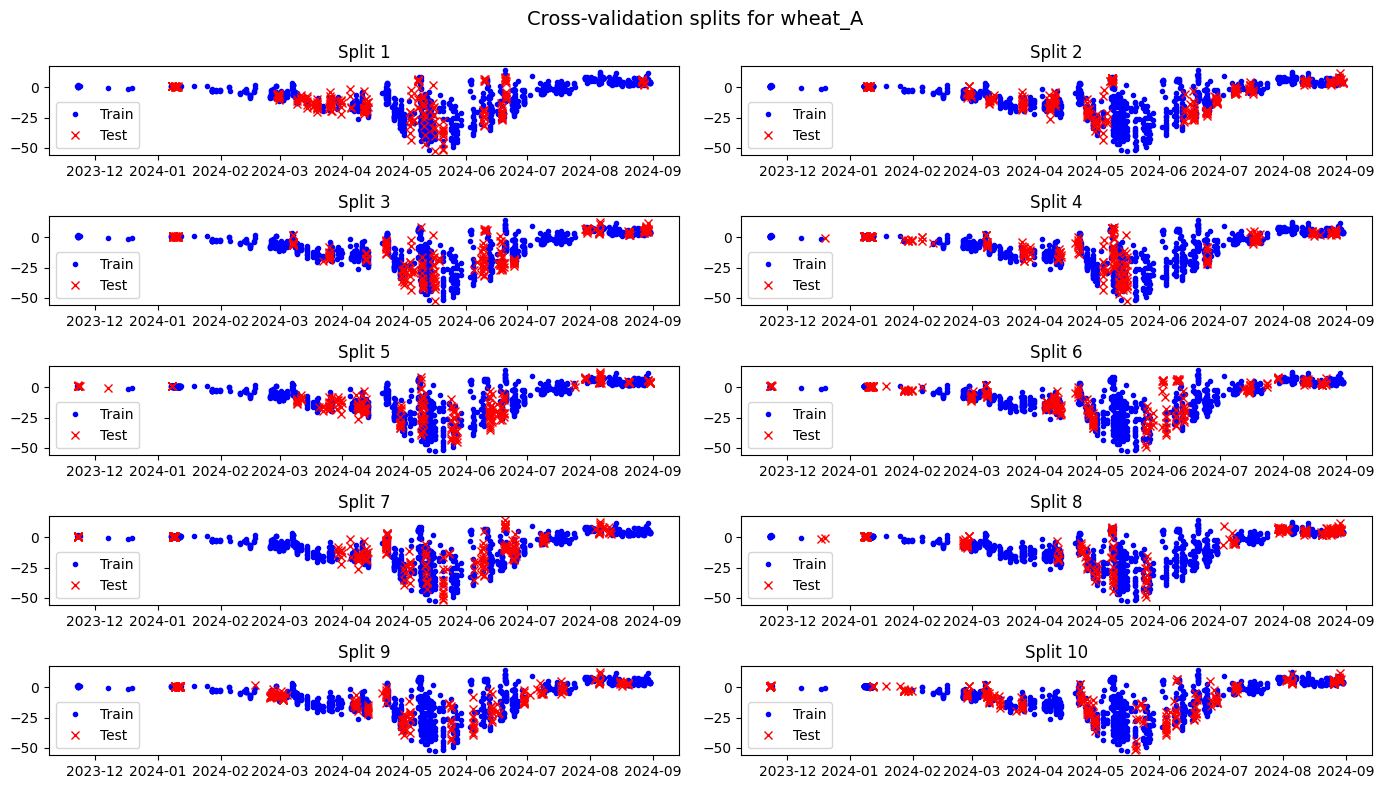

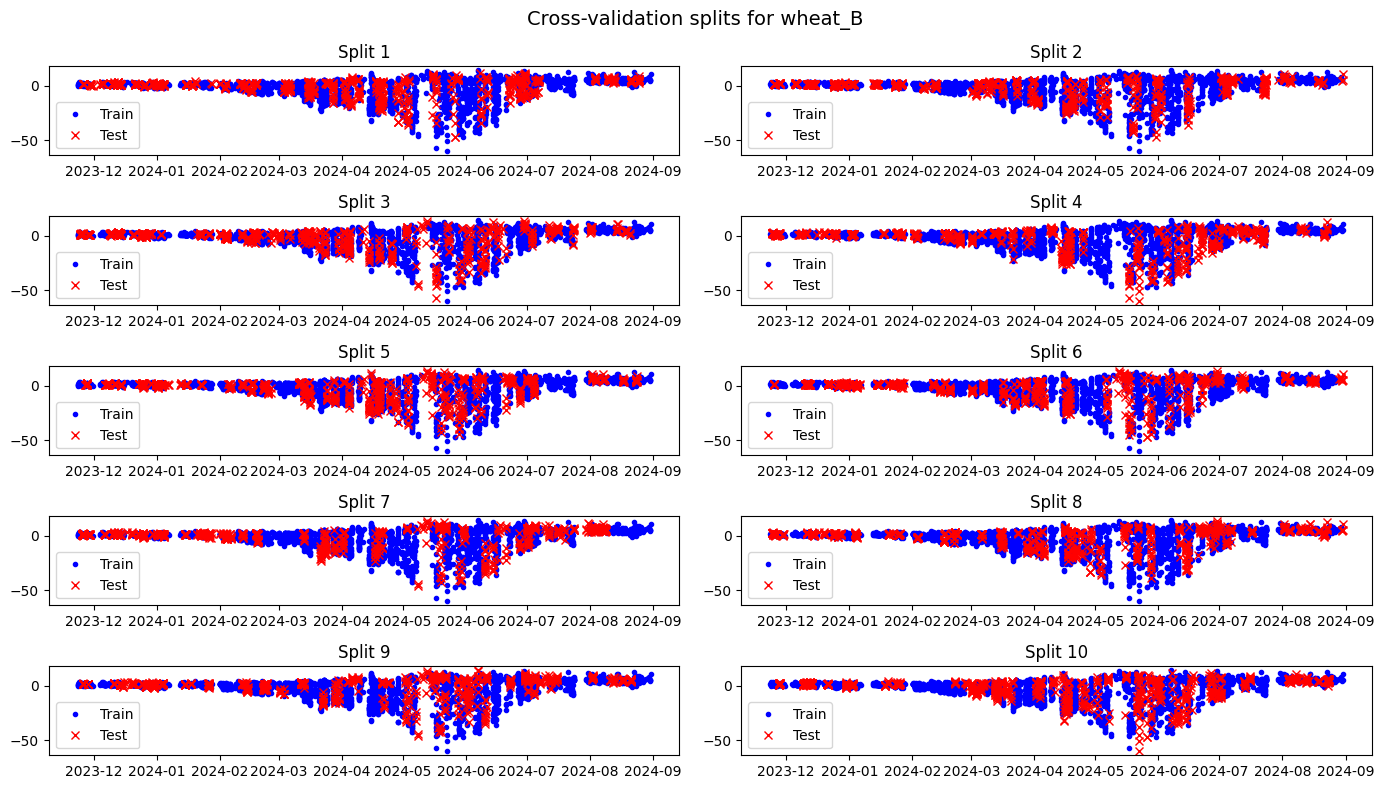

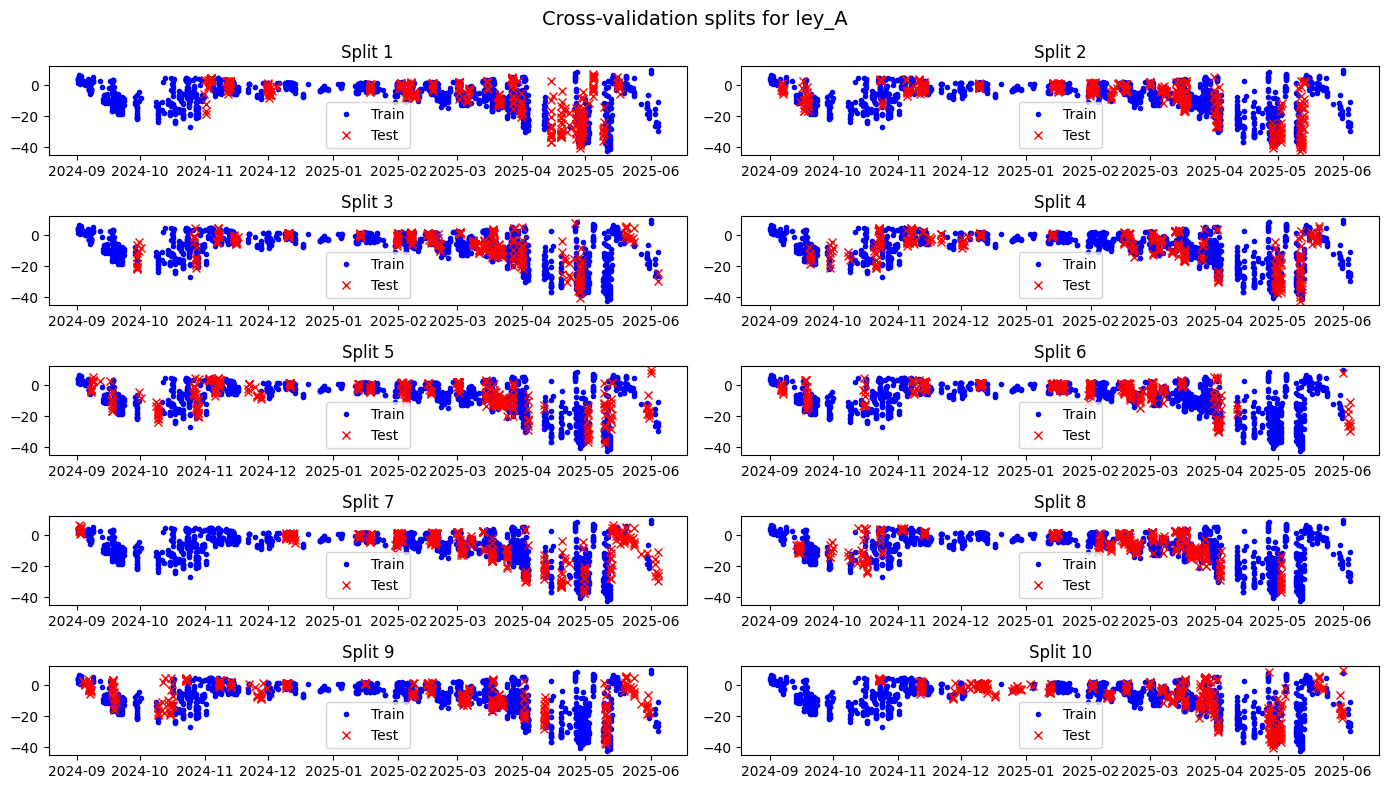

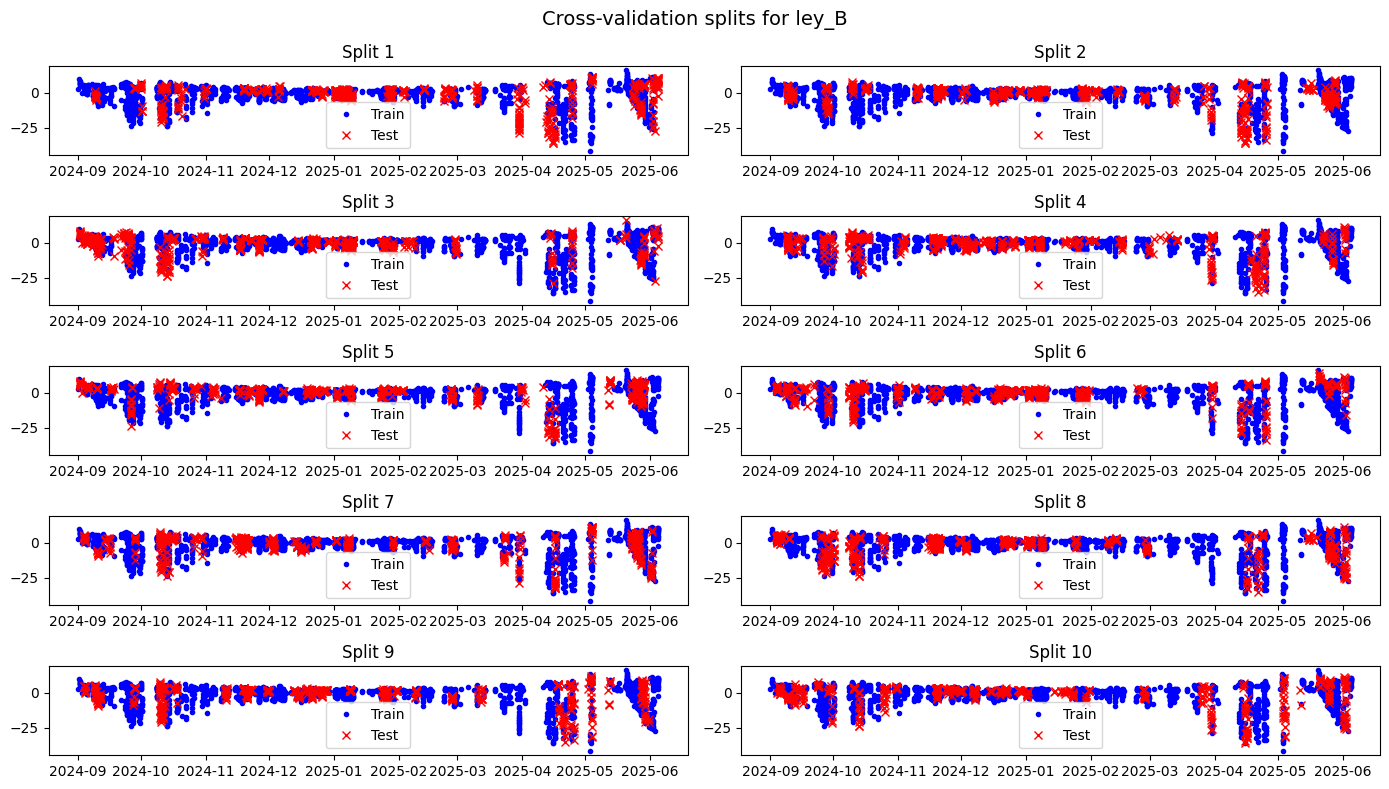

In [139]:
def create_splits(X, y, n_folds, test_size=0.2, random_state=42, n_bins=5):
    """Creates train-test splits using StratifiedShuffleSplit or StratifiedKFold with equal-width binning."""
    
    # Use pd.cut to create equal-width bins (avoids empty bins issue)
    y_binned = pd.cut(y, bins=n_bins, labels=False, include_lowest=True)

    # Select method for stratified splitting
    if CROSSVAL_SPLIT == "shuffle":
        splitter = StratifiedShuffleSplit(n_splits=n_folds, test_size=test_size, random_state=random_state)
    elif CROSSVAL_SPLIT == "kfold":
        splitter = StratifiedKFold(n_splits=n_folds, shuffle=False)

    # Generate train-test splits
    splits = [(train_idx, test_idx) for train_idx, test_idx in splitter.split(X, y_binned)]

    return splits

if CROSSVAL_SPLIT == 'time_blocks_eliza':
    def create_splits(X, y, n_folds, split=0.2, mean_block = 12, min_block=1, random_state=42): # you can set mean block to median_nan_size
        """Generates multiple train-test index splits using block-based cross-validation by varying the random seed."""
        splits = []
        total_test = round(len(X) * split)
        n_blocks = round(total_test/mean_block)

        if mean_block < min_block:
            raise ValueError("Min block size is too large for the number of blocks.")

        for fold in range(n_folds):
            np.random.seed(random_state + fold)  # Change seed for each fold
            
            tt = np.zeros(len(X))  # Array to store train-test assignments

            # Generate random block sizes with normal variation
            blocks = np.array([max(min_block, mean_block + round(v)) 
                            for v in np.random.normal(0, mean_block / 10, n_blocks)])

            # Randomly shuffle the starting positions of test blocks
            available_positions = np.arange(len(X))  # Possible start positions
            np.random.shuffle(available_positions)   # Shuffle them

            # Assign blocks sequentially based on shuffled positions
            assigned = set()
            for b in blocks:
                if len(assigned) >= total_test:
                    break
                # Pick a random starting position
                istart = np.random.choice(available_positions)
                iend = min(istart + int(b), len(X))

                # Ensure blocks don't overlap significantly
                assigned.update(range(istart, iend))
                tt[istart:iend] = 1

            train_idx = np.where(tt == 0)[0]
            test_idx = np.where(tt == 1)[0]
            
            splits.append((train_idx, test_idx))

        return splits

data_dict = {}
for name, df in subset_dict.items():
    X = df.drop(columns=TARGET)
    y = df[TARGET]
    splits = create_splits(X, y, n_folds=N_FOLDS)

    # Store everything together
    data_dict[name] = {
        "data": df,     # original dataframe
        "X": X,         # features
        "y": y,         # target
        "crossval_splits": splits  # cross-val splits
    }


# --- PLOT TRAIN-TEST SPLITS ---
for name, bundle in data_dict.items():
    X = bundle["X"]
    y = bundle["y"]
    splits = bundle["crossval_splits"]

    n_rows = math.ceil(len(splits) / 2)  # 2 columns
    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 8))
    axes = axes.flatten()

    for i, (train_idx, test_idx) in enumerate(splits):
        train_idx_mapped = X.iloc[train_idx].index
        test_idx_mapped = X.iloc[test_idx].index

        # Plot train and test
        axes[i].plot(y.loc[train_idx_mapped].index,
                     y.loc[train_idx_mapped],
                     '.', label='Train', color="blue")
        axes[i].plot(y.loc[test_idx_mapped].index,
                     y.loc[test_idx_mapped],
                     'x', label='Test', color="red")

        axes[i].set_title(f"Split {i+1}")
        axes[i].legend()

    # Hide unused subplots if n_folds is odd
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"Cross-validation splits for {name}", fontsize=14)
    plt.tight_layout()
    plt.show()

# CROSS-VALIDATION

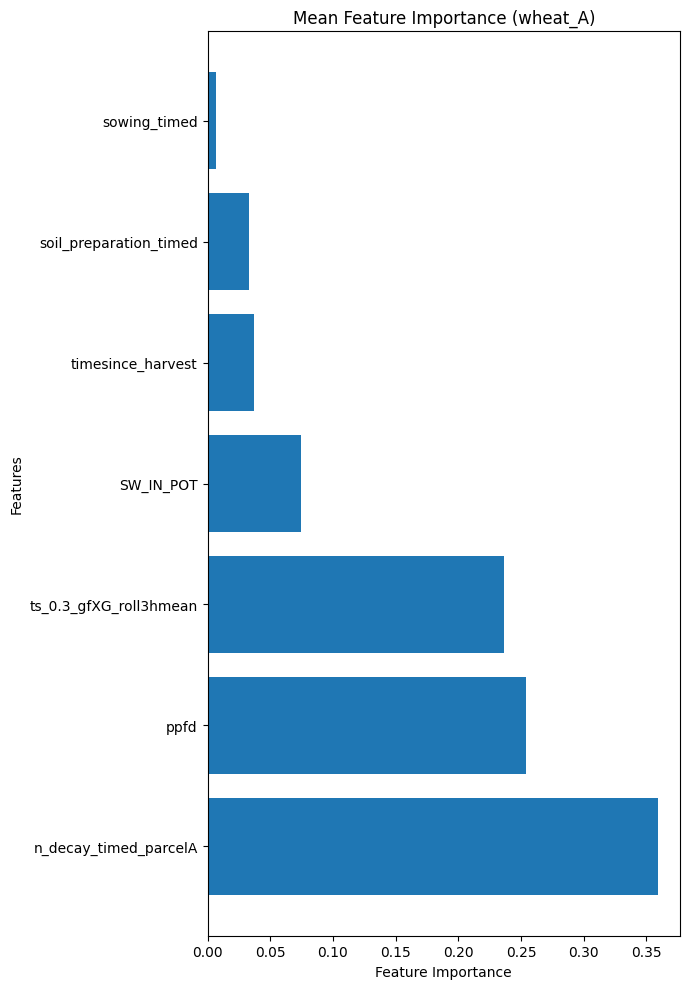

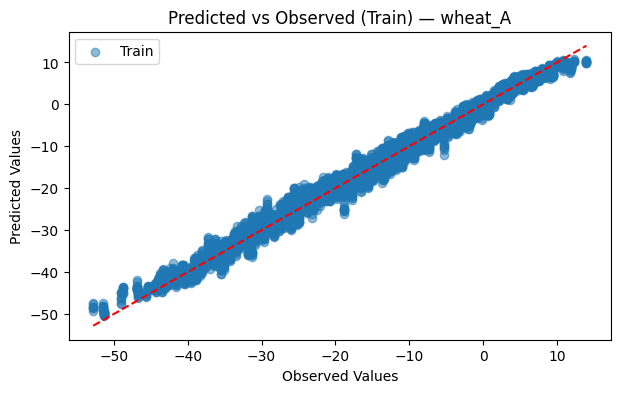

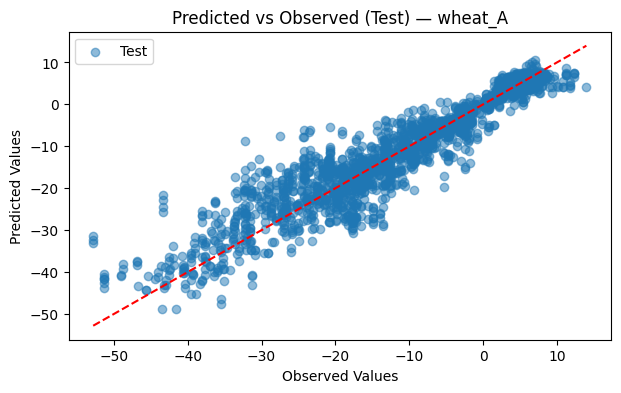

=== wheat_A ===
Train RMSE per fold: [1.3223 1.264  1.2739 1.347  1.2436 1.3458 1.2432 1.3409 1.2875 1.2732]
Mean Train RMSE: 1.2941
Test RMSE per fold: [4.6142 4.1474 5.6799 3.7523 4.3086 3.7883 5.0707 3.6482 3.9189 3.9046]
Mean Test RMSE: 4.2833
Train R² per fold: [0.9904 0.9918 0.9905 0.99   0.9914 0.9904 0.9915 0.9898 0.9913 0.9913]
Mean Train R²: 0.9908
Test R² per fold: [0.8701 0.8702 0.856  0.9261 0.8985 0.9098 0.8609 0.9268 0.8959 0.9063]
Mean Test R²: 0.8921


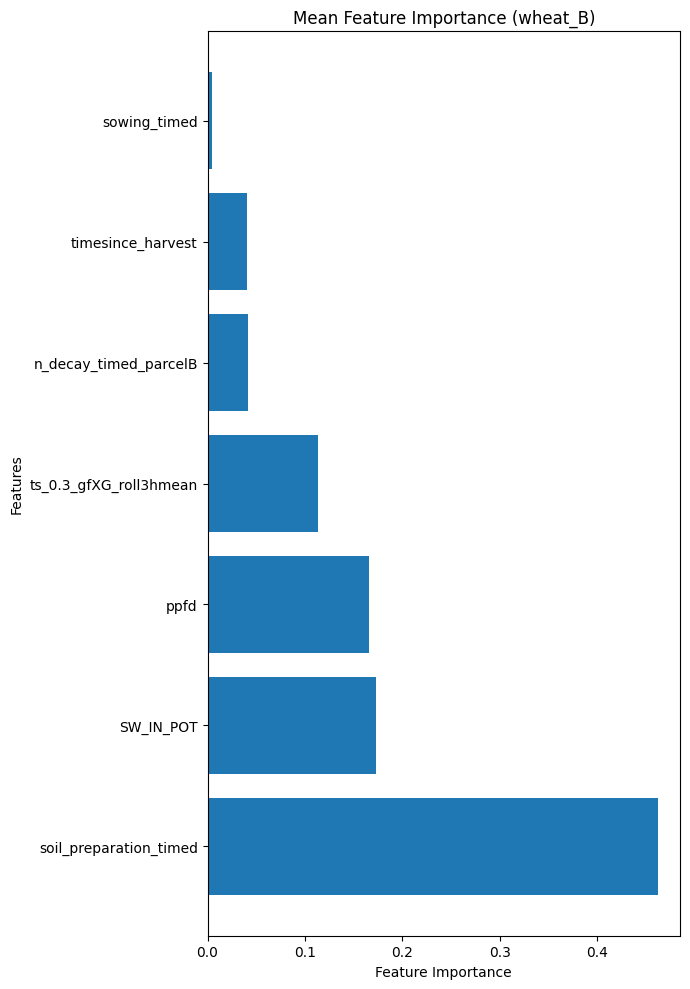

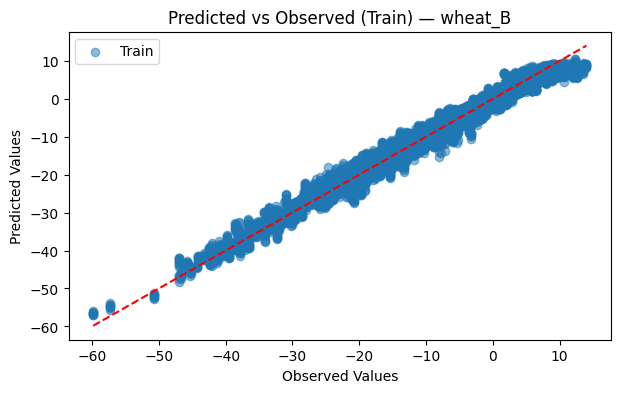

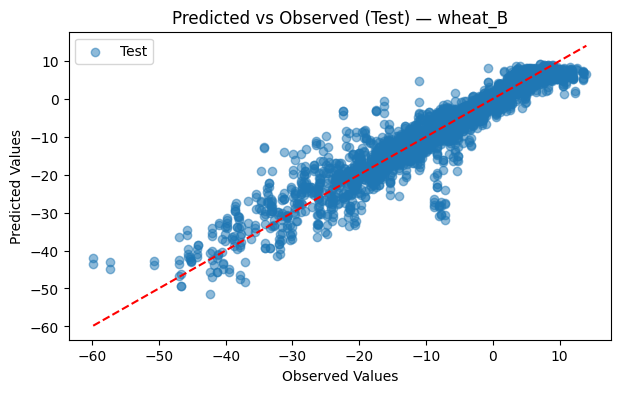

=== wheat_B ===
Train RMSE per fold: [1.1268 1.1326 1.1455 1.1607 1.0795 1.1606 1.1486 1.0939 1.172  1.1156]
Mean Train RMSE: 1.1336
Test RMSE per fold: [2.6103 2.6621 2.6034 2.5721 3.0872 2.0778 2.1642 2.7773 2.0208 2.8079]
Mean Test RMSE: 2.5383
Train R² per fold: [0.985  0.9841 0.9833 0.9817 0.9851 0.9827 0.9839 0.9854 0.9829 0.9837]
Mean Train R²: 0.9838
Test R² per fold: [0.8933 0.9121 0.9253 0.9417 0.8964 0.954  0.9375 0.8972 0.9496 0.9207]
Mean Test R²: 0.9228


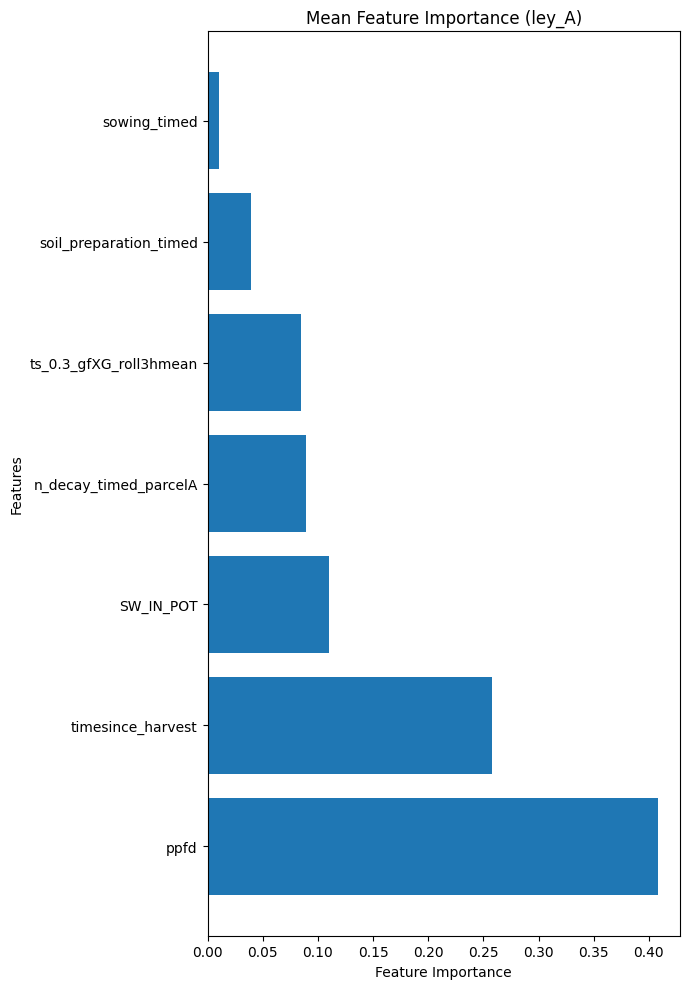

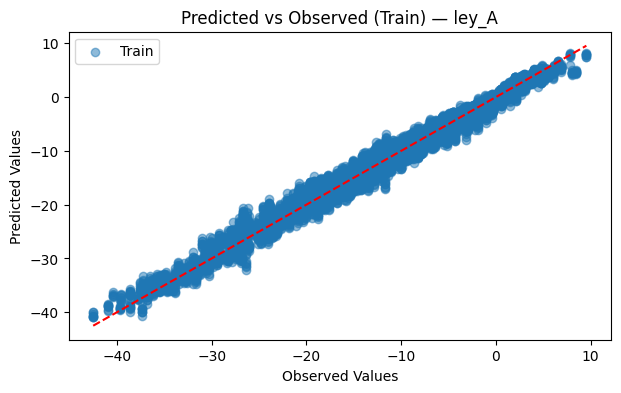

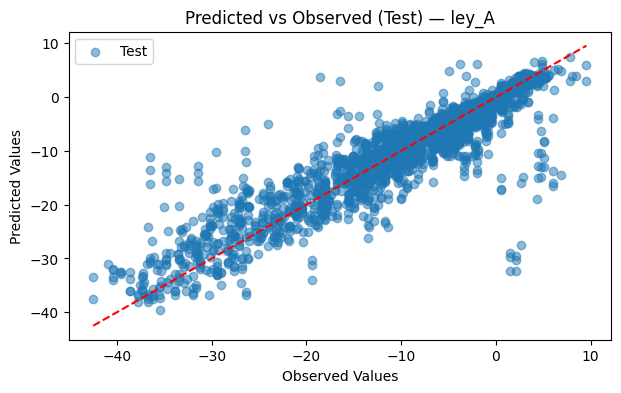

=== ley_A ===
Train RMSE per fold: [1.025  1.0562 1.0843 1.1025 1.0005 1.1736 1.0371 1.0681 1.0147 1.0471]
Mean Train RMSE: 1.0609
Test RMSE per fold: [3.2511 3.6336 3.3592 3.4143 3.9588 2.821  5.0193 2.924  3.4704 4.0355]
Mean Test RMSE: 3.5887
Train R² per fold: [0.9875 0.9879 0.9882 0.9868 0.99   0.9867 0.9886 0.9888 0.9897 0.9878]
Mean Train R²: 0.9882
Test R² per fold: [0.929  0.8868 0.861  0.9014 0.8008 0.8438 0.7663 0.8771 0.8455 0.8701]
Mean Test R²: 0.8582


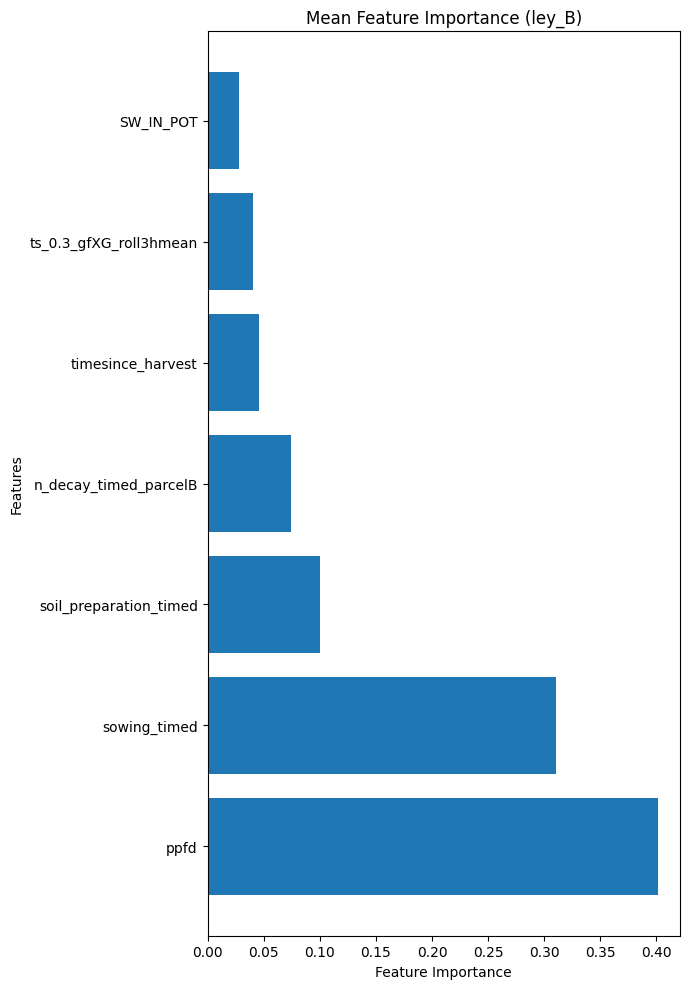

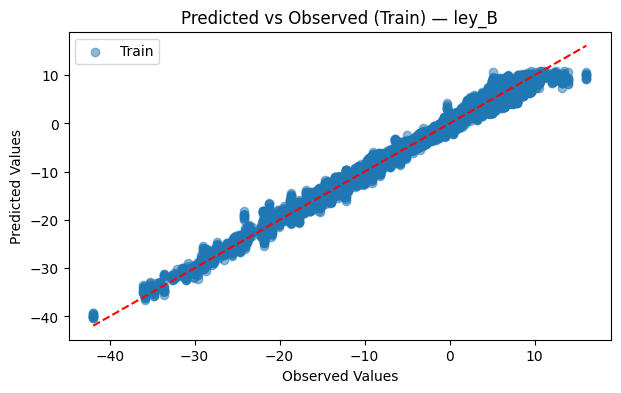

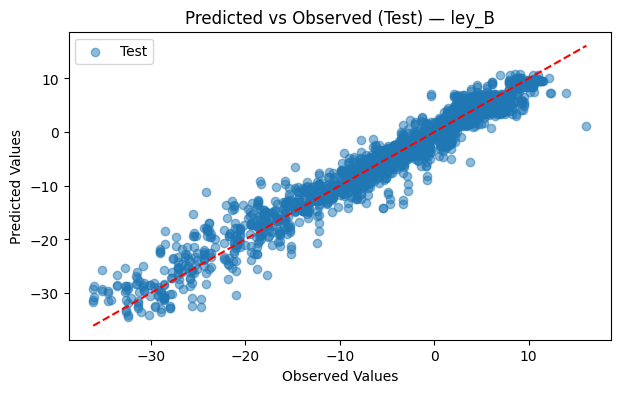

=== ley_B ===
Train RMSE per fold: [0.8519 0.8613 0.8316 0.8691 0.8677 0.8762 0.8757 0.824  0.8628 0.8638]
Mean Train RMSE: 0.8584
Test RMSE per fold: [1.5686 1.8531 1.7566 1.2425 1.7476 1.207  1.5048 1.9038 1.5669 1.5629]
Mean Test RMSE: 1.5914
Train R² per fold: [0.9849 0.9856 0.9877 0.9855 0.9863 0.9861 0.9851 0.9865 0.9856 0.9851]
Mean Train R²: 0.9858
Test R² per fold: [0.9664 0.9408 0.9172 0.9723 0.9256 0.9635 0.9608 0.9413 0.9567 0.9619]
Mean Test R²: 0.9507


In [140]:
results = {}

for name, bundle in data_dict.items():
    X = bundle["X"]
    y = bundle["y"]
    cross_val_splits = bundle["crossval_splits"]

    # Storage
    rmse_train_values, rmse_test_values = [], []
    r2_train_values, r2_test_values = [], []
    feature_importances_folds = []
    y_train_all, y_train_pred_all = [], []
    y_test_all, y_pred_test_all = [], []

    for train_idx, test_idx in cross_val_splits:  
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)

        # Predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        if LOG_TRANSFORM:
            y_train       = inverse_log_transform(y_train)
            y_test        = inverse_log_transform(y_test)
            y_train_pred  = inverse_log_transform(y_train_pred)
            y_test_pred   = inverse_log_transform(y_test_pred)

        # Metrics
        rmse_train_values.append(root_mean_squared_error(y_train, y_train_pred))
        rmse_test_values.append(root_mean_squared_error(y_test, y_test_pred))
        r2_train_values.append(r2_score(y_train, y_train_pred))
        r2_test_values.append(r2_score(y_test, y_test_pred))

        # Feature importance
        feature_importances_folds.append(model.feature_importances_)

        # Predictions for scatter
        y_train_all.extend(y_train)
        y_train_pred_all.extend(y_train_pred)
        y_test_all.extend(y_test)
        y_pred_test_all.extend(y_test_pred)

    # Aggregate feature importance
    feature_importances = np.nanmean(feature_importances_folds, axis=0)
    order = np.argsort(-feature_importances)
    feature_names = X.columns[order]

    # --- Plotting per dataset ---
    # Feature importances
    fig, ax = plt.subplots(figsize=(7, 10))
    ax.barh(feature_names, feature_importances[order])
    ax.set_xlabel("Feature Importance")
    ax.set_ylabel("Features")
    ax.set_title(f"Mean Feature Importance ({name})")
    plt.tight_layout()
    plt.show()

    # Train scatter
    plt.figure(figsize=(7, 4))
    plt.scatter(y_train_all, y_train_pred_all, alpha=0.5, label="Train")
    plt.plot([min(y_train_all), max(y_train_all)],
             [min(y_train_all), max(y_train_all)],
             color='red', linestyle='--')
    plt.xlabel("Observed Values")
    plt.ylabel("Predicted Values")
    plt.title(f"Predicted vs Observed (Train) — {name}")
    plt.legend()
    plt.show()

    # Test scatter
    plt.figure(figsize=(7, 4))
    plt.scatter(y_test_all, y_pred_test_all, alpha=0.5, label="Test")
    plt.plot([min(y_test_all), max(y_test_all)],
             [min(y_test_all), max(y_test_all)],
             color='red', linestyle='--')
    plt.xlabel("Observed Values")
    plt.ylabel("Predicted Values")
    plt.title(f"Predicted vs Observed (Test) — {name}")
    plt.legend()
    plt.show()

    # Print metrics
    print(f"=== {name} ===")
    print(f"Train RMSE per fold: {np.array(rmse_train_values).round(4)}")
    print(f"Mean Train RMSE: {np.mean(rmse_train_values):.4f}")
    print(f"Test RMSE per fold: {np.array(rmse_test_values).round(4)}")
    print(f"Mean Test RMSE: {np.mean(rmse_test_values):.4f}")
    print(f"Train R² per fold: {np.array(r2_train_values).round(4)}")
    print(f"Mean Train R²: {np.mean(r2_train_values):.4f}")
    print(f"Test R² per fold: {np.array(r2_test_values).round(4)}")
    print(f"Mean Test R²: {np.mean(r2_test_values):.4f}")


# FINAL MODEL

## Split train-test

Block splitting with test blocks that can vary of size and we can define the minimum size

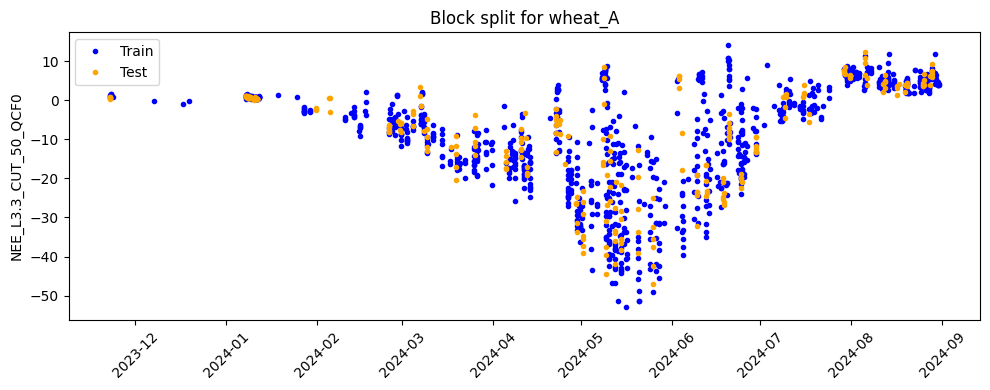

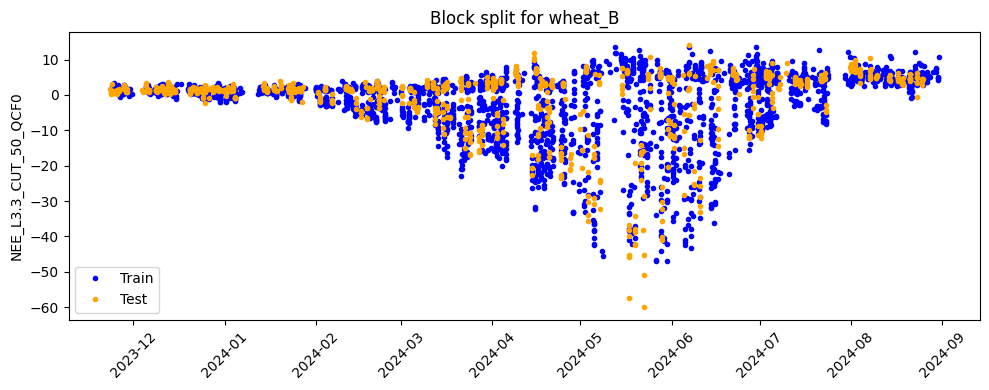

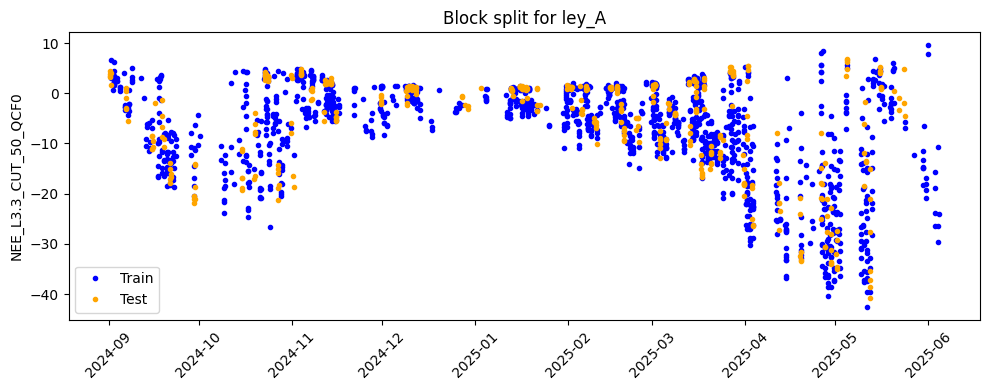

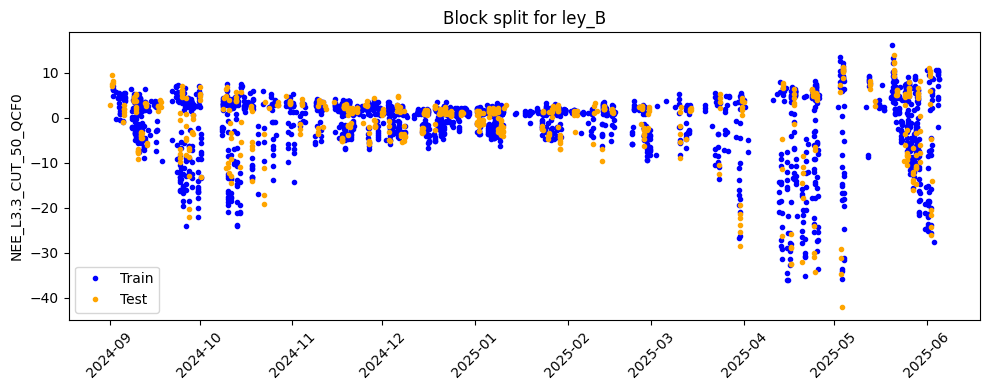

In [141]:
#mean_block = round(mean_nan_size)
mean_block = 6

def split_blocks(X, y, mean_block = mean_block, split=0.2, min_block=3):
       np.random.seed(42)  # Set seed for reproducibility
       tt = np.zeros(len(X)) # space for training/test assignments
       total_test = round(len(X)* split)
       n_blocks = round(total_test/mean_block)
       if mean_block<min_block:
              print("Error: Min block too long for this many blocks")
              return None
       # Vary the length of blocks around the mean (but not below the min)
       blocks = np.array([mean_block + round(v) for v in np.random.normal(0, mean_block/10, n_blocks)])
       blocks[blocks < min_block] = min_block
       # Assign the blocks
       for n, b in enumerate(blocks):
              istart = round(len(X)/(n_blocks))*(n-1)
              iend = istart+b
              tt[istart:iend] = 1
       X_train = X[tt==0]
       X_test = X[tt==1]
       y_train = y[tt==0]
       y_test = y[tt==1]
       # Return sorted data by index (timestamp)
       return X_train.sort_index(), X_test.sort_index(), y_train.sort_index(), y_test.sort_index(), tt

# Loop through each dataset in data_dict
for name, bundle in data_dict.items():
    X = bundle["X"]
    y = bundle["y"]

    X_train, X_test, y_train, y_test, tt = split_blocks(X, y, mean_block=6)

    # Store splits back into the dict
    data_dict[name]["final_split"] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "tt": tt,
    }

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(y_train.index, y_train, ".", label="Train", color="blue")
    ax.plot(y_test.index, y_test, ".", label="Test", color="orange")
    ax.set_ylabel(TARGET)
    ax.set_title(f"Block split for {name}")
    plt.xticks(rotation=45)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Model training and testing

[0]	validation_0-rmse:12.88465
[1]	validation_0-rmse:12.30470
[2]	validation_0-rmse:11.76340
[3]	validation_0-rmse:11.25990
[4]	validation_0-rmse:10.80555
[5]	validation_0-rmse:10.34723
[6]	validation_0-rmse:9.90633
[7]	validation_0-rmse:9.50677
[8]	validation_0-rmse:9.09428
[9]	validation_0-rmse:8.75034
[10]	validation_0-rmse:8.39440
[11]	validation_0-rmse:8.08042
[12]	validation_0-rmse:7.76611
[13]	validation_0-rmse:7.47438
[14]	validation_0-rmse:7.19126
[15]	validation_0-rmse:6.92586
[16]	validation_0-rmse:6.67399
[17]	validation_0-rmse:6.44495
[18]	validation_0-rmse:6.22464
[19]	validation_0-rmse:6.02178
[20]	validation_0-rmse:5.83839
[21]	validation_0-rmse:5.64275
[22]	validation_0-rmse:5.47164
[23]	validation_0-rmse:5.30266
[24]	validation_0-rmse:5.14511
[25]	validation_0-rmse:4.99402
[26]	validation_0-rmse:4.86680
[27]	validation_0-rmse:4.73879
[28]	validation_0-rmse:4.62308
[29]	validation_0-rmse:4.51574
[30]	validation_0-rmse:4.41689
[31]	validation_0-rmse:4.32185
[32]	validat

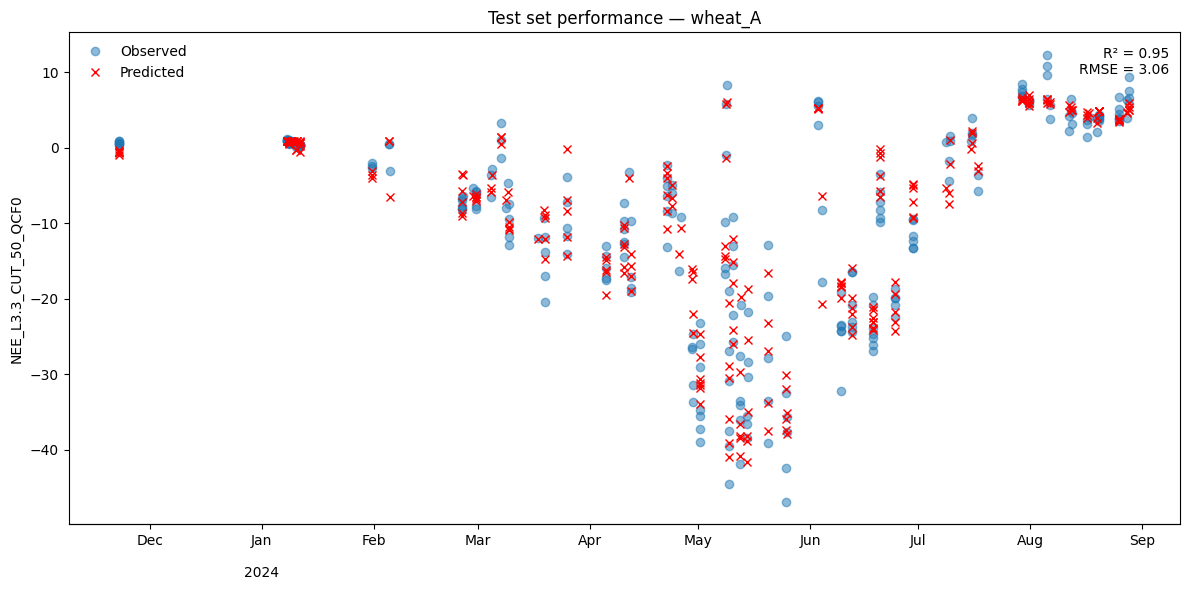

[0]	validation_0-rmse:9.41208
[1]	validation_0-rmse:9.03239
[2]	validation_0-rmse:8.67888
[3]	validation_0-rmse:8.35609
[4]	validation_0-rmse:8.03522
[5]	validation_0-rmse:7.73650
[6]	validation_0-rmse:7.46745
[7]	validation_0-rmse:7.21634
[8]	validation_0-rmse:6.95617
[9]	validation_0-rmse:6.71851
[10]	validation_0-rmse:6.49594
[11]	validation_0-rmse:6.26050
[12]	validation_0-rmse:6.05507
[13]	validation_0-rmse:5.85346
[14]	validation_0-rmse:5.66686
[15]	validation_0-rmse:5.47934
[16]	validation_0-rmse:5.30097
[17]	validation_0-rmse:5.14587
[18]	validation_0-rmse:5.00288
[19]	validation_0-rmse:4.85734
[20]	validation_0-rmse:4.71160
[21]	validation_0-rmse:4.56755
[22]	validation_0-rmse:4.45194
[23]	validation_0-rmse:4.33028
[24]	validation_0-rmse:4.21392
[25]	validation_0-rmse:4.10249
[26]	validation_0-rmse:3.99570
[27]	validation_0-rmse:3.88917
[28]	validation_0-rmse:3.79381
[29]	validation_0-rmse:3.71722
[30]	validation_0-rmse:3.64073
[31]	validation_0-rmse:3.55358
[32]	validation_0-

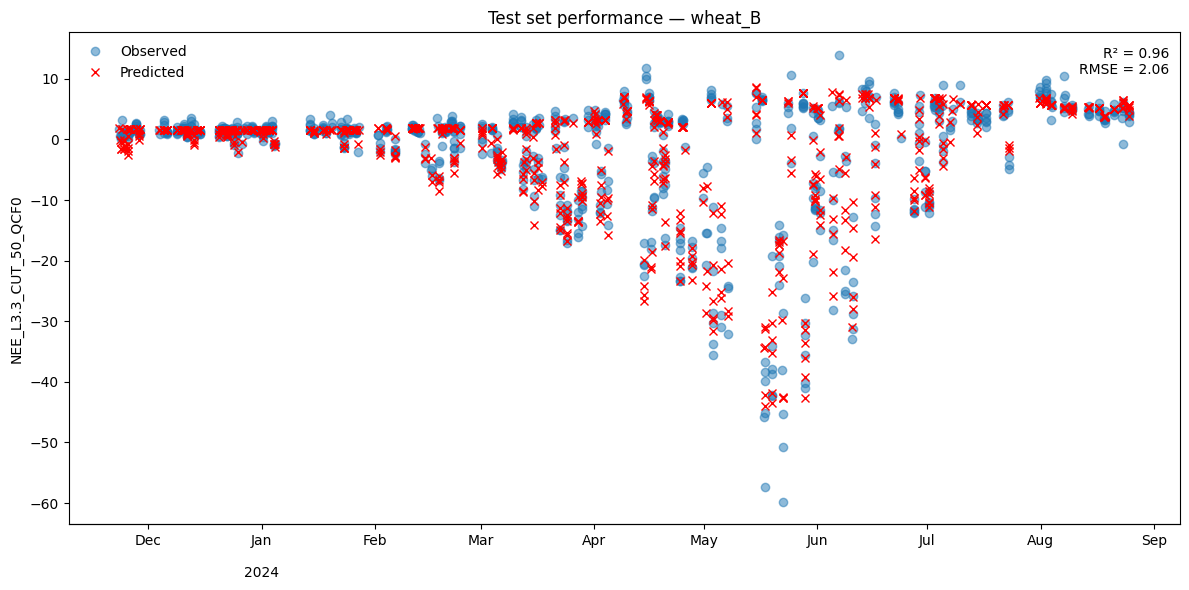

[0]	validation_0-rmse:9.75807
[1]	validation_0-rmse:9.34132
[2]	validation_0-rmse:8.94905
[3]	validation_0-rmse:8.57792
[4]	validation_0-rmse:8.26177
[5]	validation_0-rmse:7.91539
[6]	validation_0-rmse:7.60643
[7]	validation_0-rmse:7.30062
[8]	validation_0-rmse:7.03568
[9]	validation_0-rmse:6.75994
[10]	validation_0-rmse:6.49470
[11]	validation_0-rmse:6.24037
[12]	validation_0-rmse:6.01775
[13]	validation_0-rmse:5.81094
[14]	validation_0-rmse:5.61375
[15]	validation_0-rmse:5.41296
[16]	validation_0-rmse:5.22710
[17]	validation_0-rmse:5.06110
[18]	validation_0-rmse:4.90579
[19]	validation_0-rmse:4.75546
[20]	validation_0-rmse:4.61055
[21]	validation_0-rmse:4.49121
[22]	validation_0-rmse:4.36151
[23]	validation_0-rmse:4.25068
[24]	validation_0-rmse:4.13787
[25]	validation_0-rmse:4.04126
[26]	validation_0-rmse:3.95084
[27]	validation_0-rmse:3.87093
[28]	validation_0-rmse:3.78925
[29]	validation_0-rmse:3.70230
[30]	validation_0-rmse:3.61841
[31]	validation_0-rmse:3.54687
[32]	validation_0-

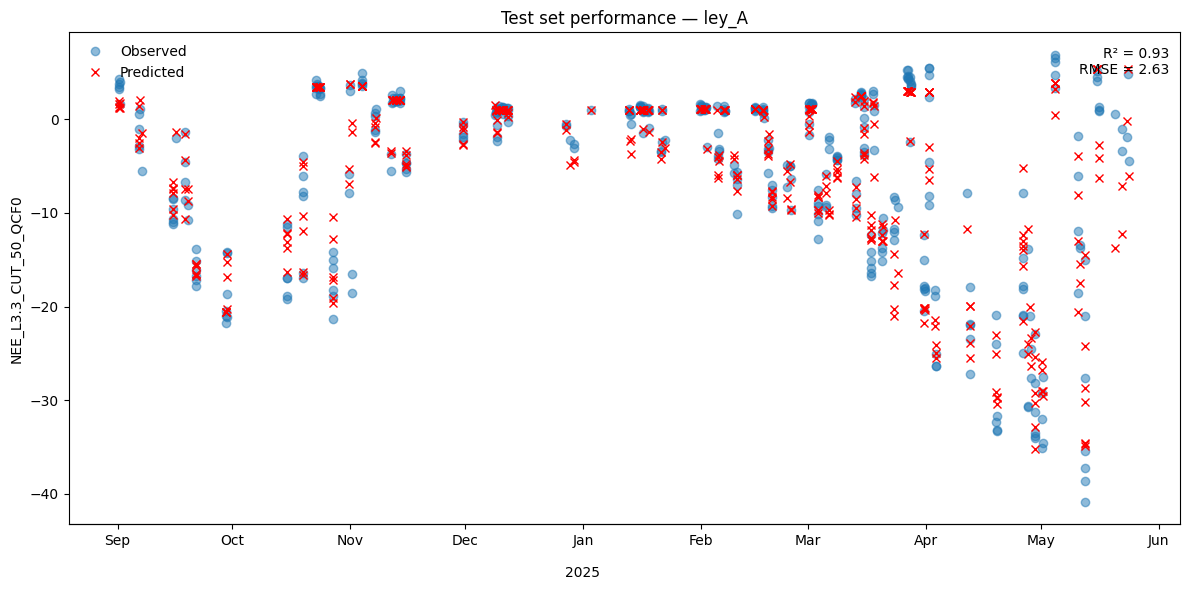

[0]	validation_0-rmse:7.45522
[1]	validation_0-rmse:7.12852
[2]	validation_0-rmse:6.81733
[3]	validation_0-rmse:6.52252
[4]	validation_0-rmse:6.25235
[5]	validation_0-rmse:5.98314
[6]	validation_0-rmse:5.73175
[7]	validation_0-rmse:5.49649
[8]	validation_0-rmse:5.27824
[9]	validation_0-rmse:5.07940
[10]	validation_0-rmse:4.88894
[11]	validation_0-rmse:4.69219
[12]	validation_0-rmse:4.50601
[13]	validation_0-rmse:4.33515
[14]	validation_0-rmse:4.17422
[15]	validation_0-rmse:4.02325
[16]	validation_0-rmse:3.89015
[17]	validation_0-rmse:3.76089
[18]	validation_0-rmse:3.63359
[19]	validation_0-rmse:3.51648
[20]	validation_0-rmse:3.39355
[21]	validation_0-rmse:3.29363
[22]	validation_0-rmse:3.19262
[23]	validation_0-rmse:3.09602
[24]	validation_0-rmse:3.01194
[25]	validation_0-rmse:2.92807
[26]	validation_0-rmse:2.84771
[27]	validation_0-rmse:2.77254
[28]	validation_0-rmse:2.70236
[29]	validation_0-rmse:2.63269
[30]	validation_0-rmse:2.56448
[31]	validation_0-rmse:2.49779
[32]	validation_0-

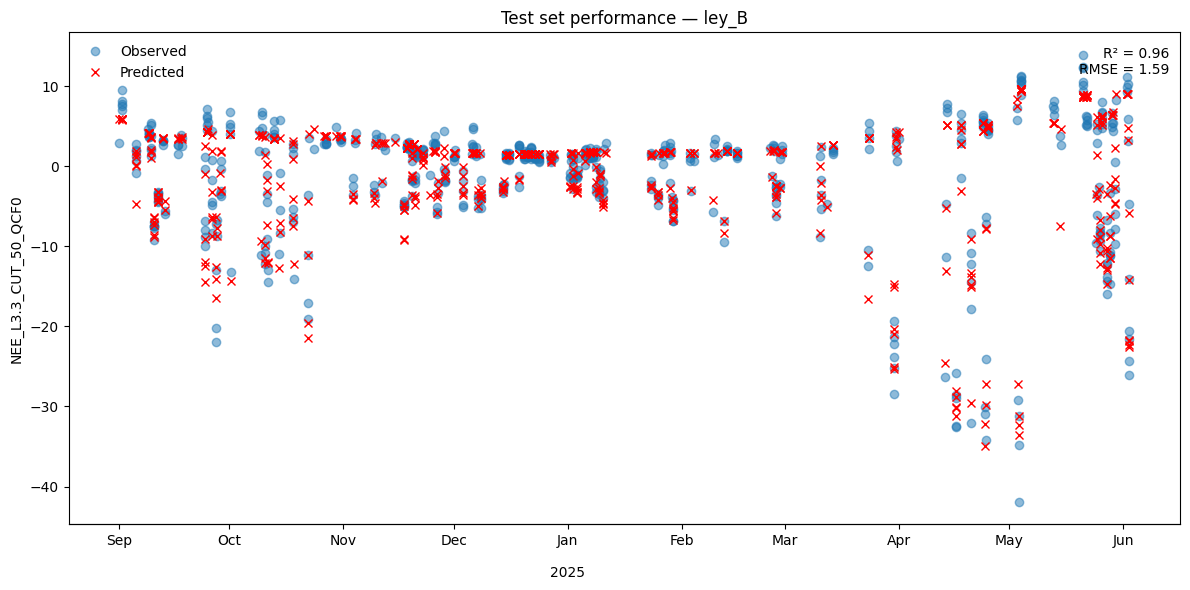

In [142]:
for name, bundle in data_dict.items():
    # Get train/test split (from block_split)
    X_train = bundle["final_split"]["X_train"]
    X_test  = bundle["final_split"]["X_test"]
    y_train = bundle["final_split"]["y_train"]
    y_test  = bundle["final_split"]["y_test"]

    # Choose model (RandomForest or XGB)
    if MODEL_TYPE == 'RandomForest':
        model = RandomForestRegressor(
            **hyperparams, random_state=42, n_jobs=-1
        )
    else:
        model = XGBRegressor(
            **hyperparams, random_state=42, n_jobs=-1,
            early_stopping_rounds=10, eval_metric="rmse"
        )

    # Train
    if MODEL_TYPE == 'RandomForest':
        model.fit(X_train, y_train)
    else:  # XGB can use eval_set
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=True)

    # Predictions
    pred_train = model.predict(X_train)
    pred_test  = model.predict(X_test)

    # Reverse log transform if needed
    if LOG_TRANSFORM:
        y_train    = inverse_log_transform(y_train)
        y_test     = inverse_log_transform(y_test)
        pred_train = inverse_log_transform(pred_train)
        pred_test  = inverse_log_transform(pred_test)

    # Metrics
    r2_train  = r2_score(y_train, pred_train)
    rmse_train = root_mean_squared_error(y_train, pred_train)
    r2_test   = r2_score(y_test, pred_test)
    rmse_test = root_mean_squared_error(y_test, pred_test)

    print(f"\n=== {name} ===")
    print(f"Train R² = {r2_train:.4f}, RMSE = {rmse_train:.4f}")
    print(f"Test  R² = {r2_test:.4f}, RMSE = {rmse_test:.4f}")

    # 👉 Save model in data_dict
    bundle["final_model"] = model

    # --- Plots ---
    # Time series plot (test set)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(y_test.index, y_test, "o", label="Observed", alpha=0.5)
    ax.plot(y_test.index, pred_test, "rx", label="Predicted")
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    secax = ax.secondary_xaxis('bottom')
    secax.xaxis.set_major_locator(mdates.YearLocator())
    secax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    secax.tick_params(axis='x', length=0, pad=30)
    ax.text(0.99, 0.97, f'R² = {r2_test:.2f}\nRMSE = {rmse_test:.2f}',
            transform=ax.transAxes, va='top', ha='right')
    ax.set_ylabel(TARGET)
    ax.legend(frameon=False, loc="upper left")
    plt.title(f"Test set performance — {name}")
    plt.tight_layout()
    plt.show()


# SHAP ANALYSIS

## RUN SHAP

In [143]:
shap_results = {}

for name, bundle in data_dict.items():
    # Use the trained model for this dataset
    model = bundle["final_model"]

    # Define background dataset (typically training set or a sample of it)
    background_dataset = data_main[list(bundle['X'].columns)]

    # Initialize SHAP explainer
    explainer = shap.TreeExplainer(model, data=background_dataset)

    # Calculate SHAP values for the entire dataset
    X = data_main[list(bundle['X'].columns)]
    shap_values = explainer(X, check_additivity=True)

    # Print expected value
    print(f"\n=== {name} ===")
    print("Baseline (expected value):", explainer.expected_value)
    if LOG_TRANSFORM:
        print("Baseline without transformation:", inverse_log_transform(explainer.expected_value))

    # Store results
    shap_results[name] = {
        "explainer": explainer,
        "shap_values": shap_values,
        "X": X
    }

 99%|===================| 27430/27648 [01:00<00:00]        


=== wheat_A ===
Baseline (expected value): -0.40234681779757425


100%|===================| 27531/27648 [01:20<00:00]        


=== wheat_B ===
Baseline (expected value): 0.32420397953044217


100%|===================| 27575/27648 [01:10<00:00]        


=== ley_A ===
Baseline (expected value): -1.0640829378948822


100%|===================| 27580/27648 [02:06<00:00]        


=== ley_B ===
Baseline (expected value): -0.5640544471143938


## SUMMARY PLOT

C:\Users\turcof\AppData\Local\Temp\ipykernel_8080\1896693884.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, show=False)


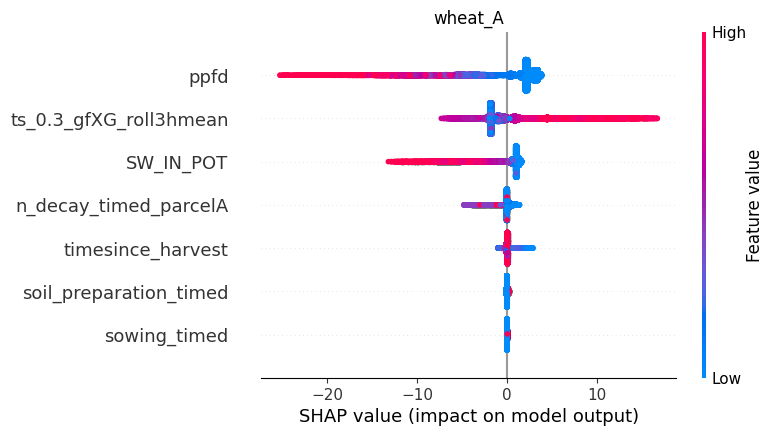

C:\Users\turcof\AppData\Local\Temp\ipykernel_8080\1896693884.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, show=False)


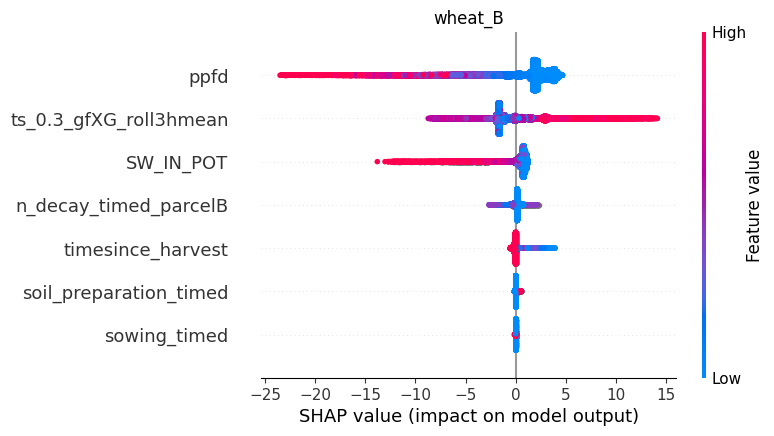

C:\Users\turcof\AppData\Local\Temp\ipykernel_8080\1896693884.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, show=False)


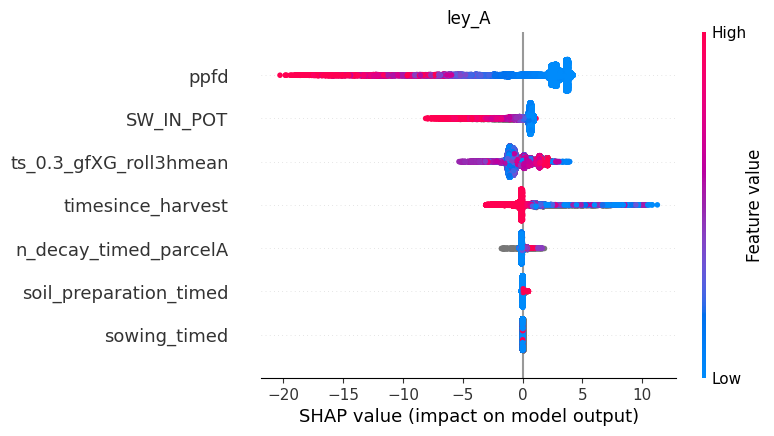

C:\Users\turcof\AppData\Local\Temp\ipykernel_8080\1896693884.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, show=False)


In [ ]:
for name, bundle in shap_results.items():
    shap_values = bundle['shap_values']
    X = bundle['X']
    # SHAP summary plot
    fig = plt.figure()
    shap.summary_plot(shap_values, X, show=False)
    plt.title(name)
    # Save the figure
    fig.savefig(f'{TARGET}_{name}_shap_summary_plot.png', dpi=300, bbox_inches='tight')
    plt.show()

## SHAP SCATTERPLOTS

In [ ]:
# Dependence plots
import math
import matplotlib.pyplot as plt

for name, bundle in shap_results.items():
    shap_values = bundle['shap_values']        # SHAP Explanation object
    X = bundle['X']

    n_features = X.shape[1]
    ncols = 3
    nrows = math.ceil(n_features / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 2*nrows))
    axes = axes.flatten()

    for i, var in enumerate(X.columns):
        axes[i].scatter(
            X[var].values,             # feature values
            shap_values.values[:, i],  # SHAP values for this feature
            s=5, alpha=0.5
        )
        axes[i].set_title(var, fontsize=9)
        axes[i].set_xlabel(var)
        axes[i].set_ylabel("SHAP value")

    # Remove unused axes
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f"SHAP dependence plots — {name}", fontsize=14)
    plt.tight_layout()

    # Save the figure
    fig.savefig(f'{TARGET}_{name}_dependence_plots.png', dpi=300, bbox_inches='tight')
    plt.show()


# GAP-FILLING

In [ ]:
QCF = 'QCF'
GAPFILLING_TARGET = f'{TARGET_FLUX}_L3.3_CUT_50_{QCF}'

# Prepare empty columns in master dataframe
for letter in ["A", "B"]:
    mask = (data_main["parcel"] == letter) & (data_main["parcel_certainty"] == "certain")
    data_main[f"{GAPFILLING_TARGET}_Parcel{letter}"] = np.where(mask, data_main[GAPFILLING_TARGET], np.nan)
    data_main[f"{GAPFILLING_TARGET}_{MODEL_TYPE}_pred_Parcel{letter}"] = np.nan
    data_main[f"{GAPFILLING_TARGET}_gf{MODEL_TYPE}_Parcel{letter}_all"] = np.nan
    data_main[f"{GAPFILLING_TARGET}_gf{MODEL_TYPE}_Parcel{letter}_certain"] = np.nan

for name, bundle in data_dict.items():
    # Parse crop and parcel from the key
    crop, letter = name.split("_")   # e.g. "wheat_A" → crop="wheat", letter="A"

    # Time period for this crop
    start, end = crop_periods[crop]

    # Slice master dataframe
    idx = (data_main.index >= start) & (data_main.index <= end)

    # Features
    X = data_main.loc[idx, bundle["X"].columns]
    model = bundle["final_model"]

    # Predict
    yhat = model.predict(X)
    if LOG_TRANSFORM:
        yhat = inverse_log_transform(yhat)

    # Column names
    col_pred    = f"{GAPFILLING_TARGET}_{MODEL_TYPE}_pred_Parcel{letter}"
    col_all     = f"{GAPFILLING_TARGET}_gf{MODEL_TYPE}_Parcel{letter}_all"
    col_certain = f"{GAPFILLING_TARGET}_gf{MODEL_TYPE}_Parcel{letter}_certain"

    # Pure predictions
    data_main.loc[idx, col_pred] = yhat

    # All version (replace where observed exists)
    yhat_all = yhat.copy()
    mask_obs = data_main.loc[idx, GAPFILLING_TARGET].notna()
    yhat_all[mask_obs] = data_main.loc[idx, GAPFILLING_TARGET][mask_obs]
    data_main.loc[idx, col_all] = yhat_all

    # Certain version (replace only where parcel_certainty is 'certain')
    yhat_certain = yhat.copy()
    mask_obs_certain = mask_obs & (data_main.loc[idx, "parcel_certainty"] == "certain")
    yhat_certain[mask_obs_certain] = data_main.loc[idx, GAPFILLING_TARGET][mask_obs_certain]
    data_main.loc[idx, col_certain] = yhat_certain

In [ ]:
# Define periods
periods = [
    ("2023-11-07", "2024-07-25", "Wheat"),
    ("2024-07-26", "2024-09-15", "Bare"),
    ("2024-09-16", "2025-06-05", "Ley"),
]

plot_pairs = [
    ("obs",    "Observations only"),
    ("pred",    "Model predictions only"),
    ("all",     "Gap-filled (all observed values)"),
    ("certain", "Gap-filled (only certain observed values)")
]

for suffix, label in plot_pairs:
    for start, end, period_name in periods:
        if suffix == "obs":
            cols = [
                f"{GAPFILLING_TARGET}_ParcelA",
                f"{GAPFILLING_TARGET}_ParcelB"
            ]
        elif suffix == "pred":
            cols = [
                f"{GAPFILLING_TARGET}_{MODEL_TYPE}_pred_ParcelA",
                f"{GAPFILLING_TARGET}_{MODEL_TYPE}_pred_ParcelB",
            ]
        
        else:
            cols = [
                f"{GAPFILLING_TARGET}_gf{MODEL_TYPE}_ParcelA_{suffix}",
                f"{GAPFILLING_TARGET}_gf{MODEL_TYPE}_ParcelB_{suffix}",
            ]

        # Slice the period
        period_df = data_main.loc[start:end, cols]

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        # Timeseries
        period_df.plot(ax=axes[0], alpha=0.7)
        axes[0].set_title(f"{period_name} — {label} (Timeseries)")
        axes[0].set_ylabel(GAPFILLING_TARGET)

        # Cumulative
        period_df.cumsum().plot(ax=axes[1])
        axes[1].set_title(f"{period_name} — {label} (Cumulative)")
        axes[1].set_ylabel(f"Cumulative {GAPFILLING_TARGET}")

        plt.suptitle(f"{label} — {period_name}", fontsize=14)
        plt.tight_layout()
        plt.show()